In [1]:
import numpy as np
import pandas as pd
import os, re, math, platform
from pathlib import Path
import matplotlib.pyplot as plt
import json
import joblib
from scipy.stats import randint as sp_randint
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import matthews_corrcoef, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_curve, auc, fbeta_score
from imblearn.metrics import geometric_mean_score
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier 
from xgboost import plot_importance
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier
from sklearn.linear_model import SGDClassifier
#from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis as PA
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
from matplotlib import pyplot
from sklearn.metrics import matthews_corrcoef, confusion_matrix,precision_recall_curve, roc_curve, auc, fbeta_score,roc_auc_score
from fea_extract import read_fasta,insert_AAC,insert_DPC,insert_CKSAAGP,insert_CTD,insert_PAAC,insert_AAI,insert_GTPC,insert_QSO,insert_AAE,insert_PSAAC,insert_word2int,insert_ASDC
import warnings 
from collections import Counter
from tools import cv,evaluate
import matplotlib.pyplot as plt
import seaborn as sns
Path('./results/balance_eval_AUC/').mkdir(exist_ok=True,parents=True) 
warnings.filterwarnings('ignore')
seed=10

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID";
os.environ["CUDA_VISIBLE_DEVICES"] = "1";

In [3]:
#!pip install lightgbm
from sklearn.ensemble import BaggingClassifier

In [4]:
seq_X_train = pd.read_csv('data/train/X_train.csv')
seq_X_test = pd.read_csv('data/test/X_test.csv')
seq_y_train = pd.read_csv('data/train/y_train.csv')
seq_y_test = pd.read_csv('data/test/y_test.csv')

In [5]:
def pro_data(seq):
    df_n = insert_PAAC(seq)
    df_n = insert_AAC(df_n)
    df_n = insert_CKSAAGP(df_n)
    df_n = insert_CTD(df_n)
    df_n = insert_DPC(df_n)
    df_n = insert_GTPC(df_n)
    df_n = insert_QSO(df_n)
    df_n = insert_AAE(df_n)
    df_n = insert_ASDC(df_n)
    #df_n = insert_word2int(df_n)
    return df_n

In [6]:
Seq_X_train = pro_data(seq_X_train)
Seq_X_test = pro_data(seq_X_test)

In [7]:
# Extract features
fea = Seq_X_train.columns[2:]
X_train = Seq_X_train[fea].to_numpy()
X_test = Seq_X_test[fea].to_numpy()

In [8]:
X_train.shape

(1969, 1296)

In [9]:
X_test.shape

(493, 1296)

In [10]:
len(fea)


1296

In [11]:
# Convert y labels
y_train = seq_y_train.to_numpy().ravel()
y_test = seq_y_test.to_numpy().ravel()

In [12]:
y_train.shape

(1969,)

In [13]:
X_train.shape

(1969, 1296)

In [14]:
y_test.shape

(493,)

In [15]:
# Separate ACPs and Non-ACPs
X_acp = Seq_X_test[y_test == 1]
X_non_acp = Seq_X_test[y_test == 0]

In [16]:
X_acp_test_orginal = X_acp[fea]

In [17]:
X_acp_test_orginal = X_acp_test_orginal.to_numpy()

In [18]:
X_non_acp_test_orginal = X_non_acp[fea]

In [19]:
X_non_acp_test_orginal = X_non_acp_test_orginal.to_numpy()

In [20]:
'''

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # Example model, can be changed
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, matthews_corrcoef
from imblearn.metrics import geometric_mean_score

# ... (Your data loading and variable definitions: X_train, y_train, X_acp_test_orginal, X_non_acp_test_orginal)

# Define imbalance ratios
imbalance_ratios = [(0.5, 0.5), (0.7, 0.3), (0.3, 0.7), (0.1, 0.9), (0.9, 0.1)]

# Metrics to calculate
metrics = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Specificity": lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0] / np.sum(y_true == 0) if np.sum(y_true == 0) > 0 else np.nan,  # Correct Specificity calculation
    "Sensitivity": recall_score,  # Sensitivity is the same as recall
    "MCC": matthews_corrcoef,
    "AUCROC": roc_auc_score,
    "AUPR": average_precision_score,
    "Gmean": geometric_mean_score,
}

results = []

for ratio in imbalance_ratios:
    print(f"Evaluating with imbalance ratio: {ratio}")

    # Create imbalanced test sets (using NumPy indexing with correct random state handling)
    n_acp = int(len(X_acp_test_orginal) * ratio[0])
    n_non_acp = int(len(X_non_acp_test_orginal) * ratio[1])

    rng = np.random.default_rng(42)  # Use default_rng for NumPy >= 1.17
    idx_acp = rng.choice(len(X_acp_test_orginal), size=n_acp, replace=False)
    idx_non_acp = rng.choice(len(X_non_acp_test_orginal), size=n_non_acp, replace=False)

    X_acp_sampled = X_acp_test_orginal[idx_acp]
    X_non_acp_sampled = X_non_acp_test_orginal[idx_non_acp]

    X_test_imbalanced = np.concatenate((X_acp_sampled, X_non_acp_sampled))
    y_test_imbalanced = np.concatenate((np.ones(len(X_acp_sampled)), np.zeros(len(X_non_acp_sampled))))

    # Train the model
    model = RandomForestClassifier(n_estimators =125, max_depth = 17, max_features='auto', random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test_imbalanced)
    y_prob = model.predict_proba(X_test_imbalanced)[:, 1] if hasattr(model, "predict_proba") else None # Check if predict_proba exists

    # Calculate metrics
    metric_values = {}
    for metric_name, metric_func in metrics.items():
        try:
            if metric_name == "AUCROC" or metric_name == "AUPR":
                if y_prob is not None: # Only calculate if y_prob exists
                  metric_values[metric_name] = metric_func(y_test_imbalanced, y_prob)
                else:
                  metric_values[metric_name] = np.nan # or some other default value
            else:
                metric_values[metric_name] = metric_func(y_test_imbalanced, y_pred)
        except Exception as e:
            print(f"Error calculating {metric_name}: {e}")
            metric_values[metric_name] = np.nan

    results.append({"ratio": ratio, **metric_values})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print the results DataFrame
print(results_df)

# Optional: Save to CSV
# results_df.to_csv("evaluation_results.csv", index=False)

'''

'\n\nimport pandas as pd\nimport numpy as np\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import RandomForestClassifier  # Example model, can be changed\nfrom sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, matthews_corrcoef\nfrom imblearn.metrics import geometric_mean_score\n\n# ... (Your data loading and variable definitions: X_train, y_train, X_acp_test_orginal, X_non_acp_test_orginal)\n\n# Define imbalance ratios\nimbalance_ratios = [(0.5, 0.5), (0.7, 0.3), (0.3, 0.7), (0.1, 0.9), (0.9, 0.1)]\n\n# Metrics to calculate\nmetrics = {\n    "Accuracy": accuracy_score,\n    "Precision": precision_score,\n    "Specificity": lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0] / np.sum(y_true == 0) if np.sum(y_true == 0) > 0 else np.nan,  # Correct Specificity calculation\n    "Sensitivity": recall_score,  # Sensitivity is the same as recall\n    "MCC": matthews_corrcoef,\n    "AUCROC": r

process_DT
Evaluating with imbalance ratio: (0.5, 0.5)
Evaluating with imbalance ratio: (0.7, 0.3)
Evaluating with imbalance ratio: (0.3, 0.7)
Evaluating with imbalance ratio: (0.1, 0.9)
Evaluating with imbalance ratio: (0.9, 0.1)
process_LGBM
[LightGBM] [Info] Number of positive: 1094, number of negative: 875
[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.038568 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 85021
[LightGBM] [Info] Number of data points in the train set: 1969, number of used features: 1190
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.555612 -> initscore=0.223372
[LightGBM] [Info] Start training from score 0.223372
Evaluating with imbalance ratio: (0.5, 0.5)
Evaluating with imbalance ratio: (0.7, 0.3)
Evaluating with imbalance ratio: (0.3, 0.7)
Evaluating with imbalance ratio: (0.1, 0.9)
Evaluating with imbalance ratio: (0.9, 0.1)
process_XGBoost
Evaluating with imbalance 

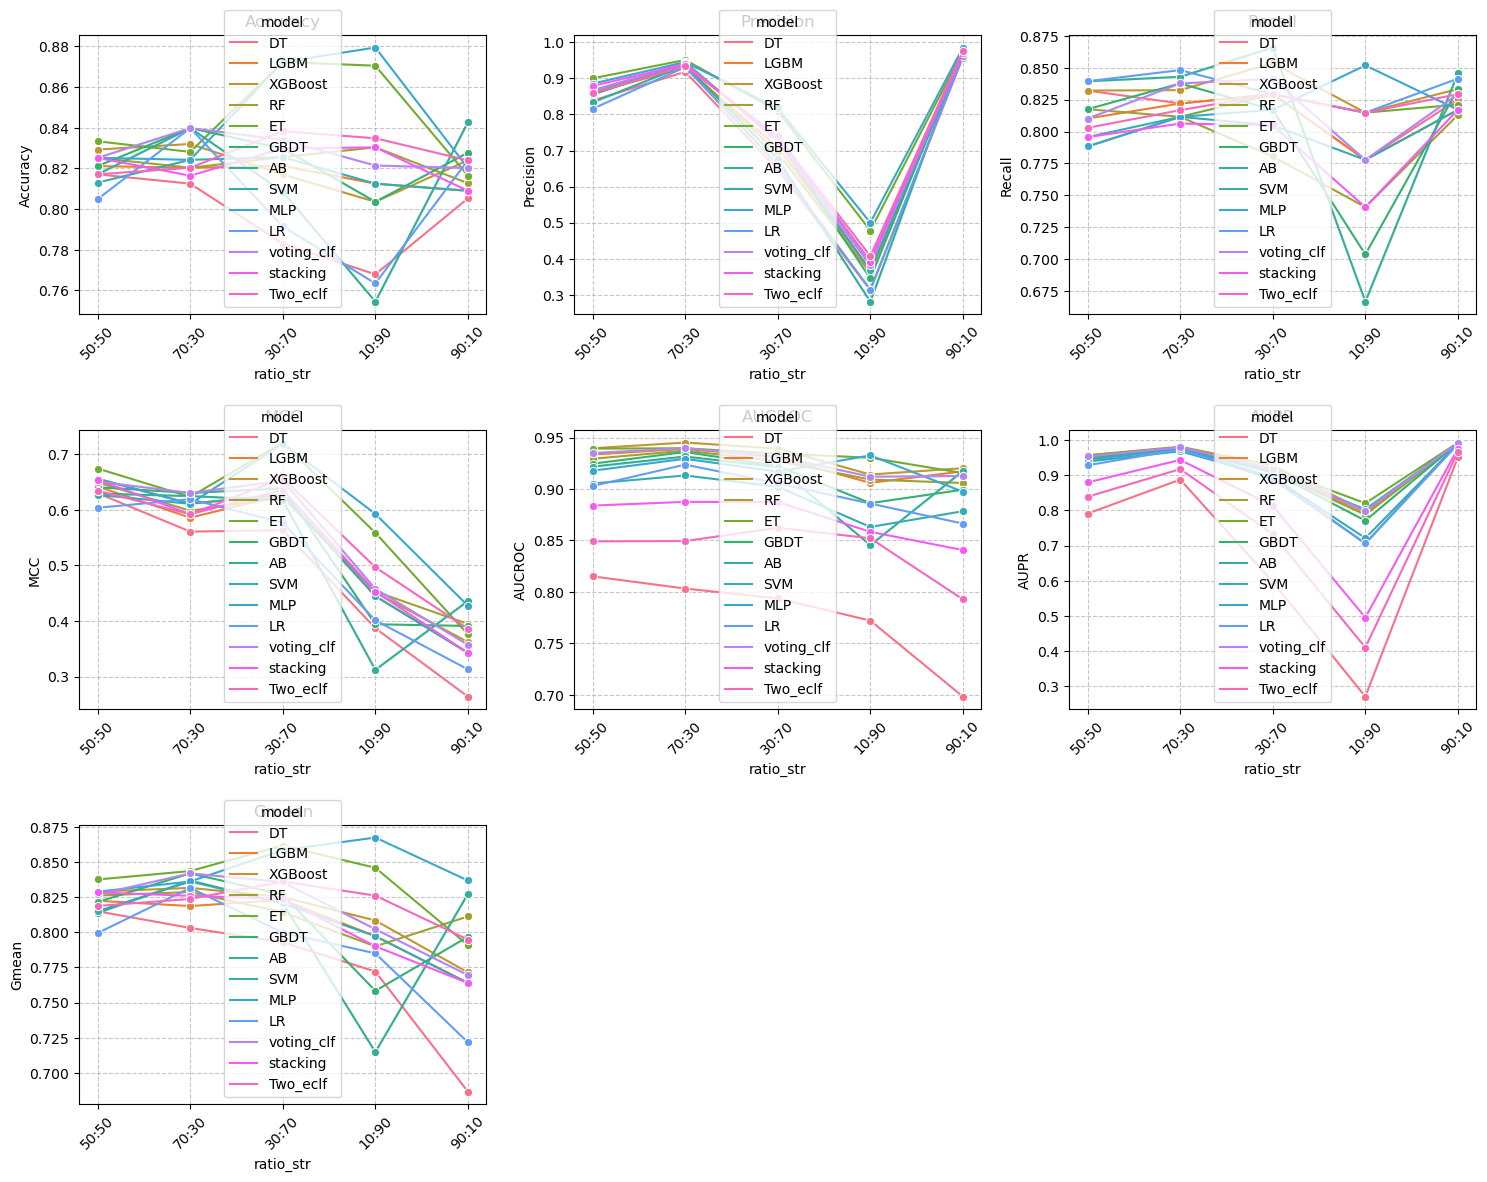

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from mlxtend.classifier import StackingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix
from imblearn.metrics import geometric_mean_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Sample Data Generation (REPLACE THIS WITH YOUR ACTUAL DATA LOADING) ---
# This section is ONLY for demonstration.  Replace it with your actual data loading.
np.random.seed(42)
# Define imbalance ratios
imbalance_ratios = [(0.5, 0.5), (0.7, 0.3), (0.3, 0.7), (0.1, 0.9), (0.9, 0.1)]

# Define models
seed = 42

layer_one = [LGBMClassifier(random_state=seed), ExtraTreesClassifier(random_state=seed), RandomForestClassifier(random_state=seed), MLPClassifier(hidden_layer_sizes=700, learning_rate="adaptive", random_state=seed)]
layer_two = [SVC(random_state=seed, probability=True), ExtraTreesClassifier(random_state=seed), RandomForestClassifier(random_state=seed), LGBMClassifier(random_state=seed)]
layer_two_meta = StackingClassifier(classifiers=layer_two, meta_classifier=LogisticRegression())

DT = DecisionTreeClassifier(random_state=seed)
LGBM = LGBMClassifier(random_state=seed)
GBDT = GradientBoostingClassifier(random_state=seed)
ET = ExtraTreesClassifier(random_state=seed)
SVM = SVC(random_state=seed, probability=True)
MLP = MLPClassifier(hidden_layer_sizes=700, learning_rate="adaptive", random_state=seed)
RF = RandomForestClassifier(random_state=seed)
XGBoost = XGBClassifier(random_state=seed)
LR = LogisticRegression(random_state=seed, solver='liblinear')
AB = AdaBoostClassifier(random_state=seed)

voting_clf = VotingClassifier(estimators=[('lgbm', LGBM), ('rf', RF), ('xgb', XGBoost), ('ET', ET), ('GBDT', GBDT)], voting='soft')
Bagging_clf = BaggingClassifier(base_estimator=RandomForestClassifier(random_state=seed))
stacking = StackingClassifier(classifiers=[LGBM, RF, XGBoost, ET, GBDT], meta_classifier=LR)
Two_eclf = StackingClassifier(classifiers=layer_one, meta_classifier=layer_two_meta)

ml = ["DT", "LGBM", "XGBoost", "RF", "ET", "GBDT", "AB", "SVM", "MLP", "LR", "AB", "voting_clf", "stacking", "Two_eclf", "voting_clf"]
models = [DT, LGBM, XGBoost, RF, ET, GBDT, AB, SVM, MLP, LR, AB, voting_clf, stacking, Two_eclf, voting_clf]


# Metrics to calculate
metrics = {
    "Accuracy": accuracy_score,
    "Precision": precision_score,
    "Recall": recall_score,
    "Specificity": lambda y_true, y_pred: confusion_matrix(y_true, y_pred)[0, 0] / np.sum(y_true == 0) if np.sum(y_true == 0) > 0 else np.nan,
    "MCC": matthews_corrcoef,
    "AUCROC": roc_auc_score,
    "AUPR": average_precision_score,
    "Gmean": geometric_mean_score,
}

results = []

for i, model in enumerate(models):
    model_name = ml[i]
    print(f'process_{model_name}')
    model.fit(X_train, y_train)

    for ratio in imbalance_ratios:
        print(f"Evaluating with imbalance ratio: {ratio}")
        n_acp = int(len(X_acp_test_orginal) * ratio[0])
        n_non_acp = int(len(X_non_acp_test_orginal) * ratio[1])

        rng = np.random.default_rng(42)
        idx_acp = rng.choice(len(X_acp_test_orginal), size=n_acp, replace=False)
        idx_non_acp = rng.choice(len(X_non_acp_test_orginal), size=n_non_acp, replace=False)

        X_acp_sampled = X_acp_test_orginal[idx_acp]
        X_non_acp_sampled = X_non_acp_test_orginal[idx_non_acp]

        X_test_imbalanced = np.concatenate((X_acp_sampled, X_non_acp_sampled))
        y_test_imbalanced = np.concatenate((np.ones(len(X_acp_sampled)), np.zeros(len(X_non_acp_sampled))))

        y_pred = model.predict(X_test_imbalanced)
        y_prob = model.predict_proba(X_test_imbalanced)[:, 1] if hasattr(model, "predict_proba") else None

        eval_dictionary = {}
        for metric_name, metric_func in metrics.items():
            try:
                if metric_name == "AUCROC" or metric_name == "AUPR":
                    if y_prob is not None:
                        eval_dictionary[metric_name] = metric_func(y_test_imbalanced, y_prob)
                    else:
                        eval_dictionary[metric_name] = np.nan
                else:
                    eval_dictionary[metric_name] = metric_func(y_test_imbalanced, y_pred)
            except Exception as e:
                print(f"Error calculating {metric_name}: {e}")
                eval_dictionary[metric_name] = np.nan

        results.append({"model": model_name, "ratio": ratio, **eval_dictionary})

ALL_eval_test = pd.DataFrame(results)

# --- Convert 'ratio' to string representation for better visualization ---
ALL_eval_test['ratio_str'] = ALL_eval_test['ratio'].apply(lambda r: f"{r[0]*100:.0f}:{r[1]*100:.0f}")

print(ALL_eval_test)

# Optional: Save to CSV
ALL_eval_test.to_csv("evaluation_results.csv", index=False)


# --- Example Plotting (Optional) ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(15, 12)) # Adjust figure size as needed
axes = axes.flatten()

i = 0
for metric in metrics:
    if metric != "Specificity": # Exclude specificity from plots if you want
        sns.lineplot(x="ratio_str", y=metric, hue="model", data=ALL_eval_test, ax=axes[i], marker='o')
        axes[i].set_title(metric)
        axes[i].tick_params(axis='x', rotation=45)  # Rotate x-axis labels
        axes[i].grid(True, linestyle='--', alpha=0.7)
        i += 1

# Remove any unused subplots
while i < len(axes):
    fig.delaxes(axes[i])
    i += 1

plt.tight_layout()
plt.show()